In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, time, timedelta
import unisacsi.Meteo as Met
import os
import numpy as np
import glob

C:\Users\carol\miniconda3\envs\AGF211\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


In [2]:
#CR1000_Radiation_Res_data_1_min_20260303_2026_03_03_13_02_08.dat
filepath_rad="C:/Users/carol/Documents/Uni/5.Semester/Svalbard/AGF212/2026/radiation/CR1000_Radiation_Res_data_1_min_202603*.dat"
filepath_temp="C:/Users/carol/Documents/Uni/5.Semester/Svalbard/AGF212/2026/kayleigh/CR850_Kayleigh_Res_data_1_min_202603*.dat"
filepath_press="C:/Users/carol/Documents/Uni/5.Semester/Svalbard/AGF212/2026/bobbyMcGee/CR1000_BobbyMcGee_Res_data_1_min_202603*.dat"
filepath_tag4="C:/Users/carol/Documents/Uni/5.Semester/Svalbard/AGF212/2026/Snowpit_tinytags/TT4_20260310.csv"
filepath_tag5="C:/Users/carol/Documents/Uni/5.Semester/Svalbard/AGF212/2026/Snowpit_tinytags/TT5_20260310.csv"
path_data = "C:/Users/carol/Documents/Uni/5.Semester/Svalbard/AGF212/OneDrive_2026-04-17/Arome_data"


### Reading+cleaning ds

#### AROME

In [3]:
ds_aa = Met.read_AROME(os.path.join(path_data,"_2p5km_202603*.nc"))
ds_aa = ds_aa.squeeze()
ds_aa

<xarray.Dataset> Size: 112kB
Dimensions:                                    (time: 216, y: 3, x: 2)
Coordinates:
  * time                                       (time) datetime64[ns] 2kB 2026...
  * y                                          (y) float32 12B 3.945e+05 ... ...
  * x                                          (x) float32 8B 8.561e+05 8.586...
    longitude                                  (y, x) float64 48B 16.04 ... 1...
    latitude                                   (y, x) float64 48B 78.24 ... 7...
    height0                                    float32 4B 0.0
    height1                                    float32 4B 2.0
    height7                                    float32 4B 10.0
Data variables: (12/18)
    T_air_2m                                   (time, y, x) float32 5kB 266.5...
    p_surface_air                              (time, y, x) float32 5kB 9.349...
    T_air_0m                                   (time, y, x) float32 5kB 266.3...
    surface_downwelling_shortwave_flux_in_air  (time, y, x) float32 5kB nan ....
    surface_downwelling_longwave_flux_in_air   (time, y, x) float32 5kB nan ....
    RH_2m                                      (time, y, x) float32 5kB 0.991...
    ...                                         ...
    u_wind_10m                                 (time, y, x) float64 10kB -11....
    v_wind_10m                                 (time, y, x) float64 10kB 3.76...
    Dir_wind_10m                               (time, y, x) float64 10kB 107....
    Speed_wind_10m                             (time, y, x) float64 10kB 12.5...
    T_air_potential_2m                         (time, y, x) float32 5kB 271.6...
    relative_humidty_2m                        (time, y, x) float32 5kB 0.990...
Attributes: (12/42)
    institution_short_name:          NO/MET
    min_time:                        2026-03-02T00:00:00Z
    geospatial_lat_min:              62.0
    geospatial_lat_max:              88.0
    geospatial_lon_min:              -18.0
    geospatial_lon_max:              80.0
    ...                              ...
    title:                           Arome-Arctic 2.5Km deterministic 2026-03...
    title_no:                        Arome-Arctic 2.5Km deterministisk 2026-0...
    related_dataset:                 no.met:806070da-e9f3-4d03-ba1d-26b843961...
    summary:                         This file contains output from Control m...
    summary_no:                      Denne filen inneholder utdata fra kontro...
    DODS_EXTRA.Unlimited_Dimension:  time

In [4]:
Temp_2m_AROME_0 = ds_aa["T_air_2m"][:, 0, 0]-273.15
Temp_2m_AROME_0['TIMESTAMP'] = ds_aa["time"]
Temp_2m_AROME_5 = ds_aa["T_air_2m"][:, 2, 0]-273.15
Temp_2m_AROME_5['TIMESTAMP'] = ds_aa["time"]
Temp_2m_AROME_2 = ds_aa["T_air_2m"][:, 1, 0]-273.15
Temp_2m_AROME_2['TIMESTAMP'] = ds_aa["time"]
Temp_2m_AROME_3 = ds_aa["T_air_2m"][:, 1, 1]-273.15
Temp_2m_AROME_3['TIMESTAMP'] = ds_aa["time"]

#Temp_2m_AROME_3

Dir_wind_10m_AROME_0 = ds_aa["Dir_wind_10m"][:, 0, 0]
Dir_wind_10m_AROME_0['TIMESTAMP'] = ds_aa["time"]
Dir_wind_10m_AROME_5 = ds_aa["Dir_wind_10m"][:, 2, 0]
Dir_wind_10m_AROME_5['TIMESTAMP'] = ds_aa["time"]
Dir_wind_10m_AROME_2 = ds_aa["Dir_wind_10m"][:, 1, 0]
Dir_wind_10m_AROME_2['TIMESTAMP'] = ds_aa["time"]
Dir_wind_10m_AROME_3 = ds_aa["Dir_wind_10m"][:, 1, 1]
Dir_wind_10m_AROME_3['TIMESTAMP'] = ds_aa["time"]

#Dir_wind_10m

Wind_speed_AROME_0 = ds_aa["Speed_wind_10m"][:, 0, 0]
Wind_speed_AROME_0['TIMESTAMP'] = ds_aa["time"]
Wind_speed_AROME_5 = ds_aa["Speed_wind_10m"][:, 2, 0]
Wind_speed_AROME_5['TIMESTAMP'] = ds_aa["time"]
Wind_speed_AROME_2 = ds_aa["Speed_wind_10m"][:, 1, 0]
Wind_speed_AROME_2['TIMESTAMP'] = ds_aa["time"]
Wind_speed_AROME_3 = ds_aa["Speed_wind_10m"][:, 1, 1]
Wind_speed_AROME_3['TIMESTAMP'] = ds_aa["time"]

#Wind_speed_AROME_3

SW_down_AROME_2 = ds_aa["surface_downwelling_shortwave_flux_in_air"][:, 1, 0]
SW_down_AROME_2['TIMESTAMP'] = ds_aa["time"]
SW_down_AROME_3 = ds_aa["surface_downwelling_shortwave_flux_in_air"][:, 1, 1]
SW_down_AROME_3['TIMESTAMP'] = ds_aa["time"]
SW_up_AROME_2 = ds_aa["surface_upwelling_shortwave_flux_in_air"][:, 1, 0]
SW_up_AROME_2['TIMESTAMP'] = ds_aa["time"]
SW_up_AROME_3 = ds_aa["surface_upwelling_shortwave_flux_in_air"][:, 1, 1]
SW_up_AROME_3['TIMESTAMP'] = ds_aa["time"]

LW_down_AROME_2 = ds_aa["surface_downwelling_longwave_flux_in_air"][:, 1, 0]
LW_down_AROME_2['TIMESTAMP'] = ds_aa["time"]
LW_down_AROME_3 = ds_aa["surface_downwelling_longwave_flux_in_air"][:, 1, 1]
LW_down_AROME_3['TIMESTAMP'] = ds_aa["time"]
LW_up_AROME_2 = ds_aa["surface_upwelling_longwave_flux_in_air"][:, 1, 0]
LW_up_AROME_2['TIMESTAMP'] = ds_aa["time"]
LW_up_AROME_3 = ds_aa["surface_upwelling_longwave_flux_in_air"][:, 1, 1]
LW_up_AROME_3['TIMESTAMP'] = ds_aa["time"]

#LW and SW up and down
RH_2m_AROME_0 = ds_aa["RH_2m"][:, 0, 0]*100
RH_2m_AROME_0['TIMESTAMP'] = ds_aa["time"]
RH_2m_AROME_5 = ds_aa["RH_2m"][:, 2, 0]*100
RH_2m_AROME_5['TIMESTAMP'] = ds_aa["time"]
RH_2m_AROME_2 = ds_aa["RH_2m"][:, 1, 0]*100
RH_2m_AROME_2['TIMESTAMP'] = ds_aa["time"]
RH_2m_AROME_3 = ds_aa["RH_2m"][:, 1, 1]*100
RH_2m_AROME_3['TIMESTAMP'] = ds_aa["time"]

#RH_2m_AROME_3

T_surface_AROME_0 = ds_aa["T_air_0m"][:, 0, 0]-273.15
T_surface_AROME_0['TIMESTAMP'] = ds_aa["time"]
T_surface_AROME_5 = ds_aa["T_air_0m"][:, 2, 0]-273.15
T_surface_AROME_5['TIMESTAMP'] = ds_aa["time"]
T_surface_AROME_2 = ds_aa["T_air_0m"][:, 1, 0]-273.15
T_surface_AROME_2['TIMESTAMP'] = ds_aa["time"]
T_surface_AROME_3 = ds_aa["T_air_0m"][:, 1, 1]-273.15
T_surface_AROME_3['TIMESTAMP'] = ds_aa["time"]

p_surface_air_AROME_2=ds_aa['p_surface_air'][:, 1, 0]
p_surface_air_AROME_2['TIMESTAMP'] = ds_aa["time"]
p_surface_air_AROME_3=ds_aa['p_surface_air'][:, 1, 1]
p_surface_air_AROME_3['TIMESTAMP'] = ds_aa["time"]


<xarray.DataArray 'surface_downwelling_shortwave_flux_in_air' (time: 216)> Size: 864B
array([            nan,  9.20974858e-14,  9.18881196e-14,             nan,
        0.00000000e+00,  0.00000000e+00,             nan,  0.00000000e+00,
        1.38666666e+00,             nan,  2.34844437e+01,  3.11288891e+01,
                   nan,  2.45333328e+01,  1.53066664e+01,             nan,
        0.00000000e+00,  0.00000000e+00,             nan,  0.00000000e+00,
        0.00000000e+00,             nan,  9.02159274e-14,  9.00796365e-14,
                   nan,  8.95692483e-14,  8.95968819e-14,             nan,
        0.00000000e+00,  0.00000000e+00,             nan,  0.00000000e+00,
        2.89777780e+00,             nan,  3.42577782e+01,  4.46222229e+01,
                   nan,  3.61422234e+01,  2.22133331e+01,             nan,
        0.00000000e+00,  0.00000000e+00,             nan,  0.00000000e+00,
        0.00000000e+00,             nan,  8.65293893e-14,  8.62208999e-14,
                   nan,  8.56800728e-14,  8.53880836e-14,             nan,
        0.00000000e+00,  0.00000000e+00,             nan,  0.00000000e+00,
        3.54666662e+00,             nan,  5.16622238e+01,  6.75199966e+01,
                   nan,  3.89333344e+01,  3.23911095e+01,             nan,
        0.00000000e+00,  0.00000000e+00,             nan,  0.00000000e+00,
        0.00000000e+00,             nan,  8.83603900e-14,  8.84542819e-14,
                   nan,  8.83520958e-14,  8.82255423e-14,             nan,
        0.00000000e+00,  0.00000000e+00,             nan,  0.00000000e+00,
...
        0.00000000e+00,             nan,  9.21645301e-14,  9.18806250e-14,
                   nan,  9.10890897e-14,  9.06927257e-14,             nan,
        0.00000000e+00,  0.00000000e+00,             nan,  8.00000012e-01,
        1.70488892e+01,             nan,  3.01866665e+01,  4.37333336e+01,
                   nan,  2.78133335e+01,  2.54666672e+01,             nan,
        9.55555558e-01, -4.44444455e-03,             nan,  0.00000000e+00,
        0.00000000e+00,             nan,  1.04083320e-13,  1.04281208e-13,
                   nan,  1.04707624e-13,  1.04723474e-13,             nan,
        0.00000000e+00,  0.00000000e+00,             nan,  1.00444448e+00,
        1.11644440e+01,             nan,  4.69422226e+01,  5.56888885e+01,
                   nan,  2.04711113e+01,  4.11111107e+01,             nan,
        3.97777772e+00,  4.44444455e-03,             nan,  0.00000000e+00,
        0.00000000e+00,             nan,  1.02278490e-13,  1.02190561e-13,
                   nan,  1.01964003e-13,  1.01853530e-13,             nan,
        0.00000000e+00,  0.00000000e+00,             nan,  5.08444452e+00,
        3.69866676e+01,             nan,  9.48088913e+01,  8.30933304e+01,
                   nan,  6.81600037e+01,  4.74133339e+01,             nan,
        8.08888912e+00,  0.00000000e+00,             nan,  0.00000000e+00,
        0.00000000e+00,             nan,  9.50124175e-14,  9.46864589e-14],
      dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 2kB 2026-03-02 ... 2026-03-10T23:00:00
    TIMESTAMP  (time) datetime64[ns] 2kB 2026-03-02 ... 2026-03-10T23:00:00
    x          float32 4B 8.561e+05
    y          float32 4B 3.97e+05
    longitude  float64 8B 16.11
    latitude   float64 8B 78.26
    height0    float32 4B 0.0
    height1    float32 4B 2.0
    height7    float32 4B 10.0
Attributes:
    long_name:      surface SW downwelling radiation
    standard_name:  surface_downwelling_shortwave_flux_in_air
    units:          W/m^2
    grid_mapping:   projection_lambert
    _ChunkSizes:    [  1   1 949 739]

#### Observations

In [5]:

Rad_Tbn = Met.read_Campbell_TOA5(filepath_rad)
Rad_Tbn = Rad_Tbn.loc['2026-03-02 14:00:00':]

Rad_Tbn = Rad_Tbn.drop(
    Rad_Tbn.loc['2026-03-03 12:40:00':'2026-03-03 13:40:00'].index
)

Rad_Tbn = Rad_Tbn.drop(
    Rad_Tbn.loc['2026-03-04 13:45:00':'2026-03-04 14:30:00'].index
)

Rad_Tbn = Rad_Tbn.drop(
    Rad_Tbn.loc['2026-03-05 12:00:00':'2026-03-05 12:30:00'].index
)

Rad_Tbn = Rad_Tbn.drop(
    Rad_Tbn.loc['2026-03-09 09:45:00':'2026-03-09 10:30:00'].index
)

Rad_Tbn = Rad_Tbn.loc[:'2026-03-10 09:10:00']


Rad_Tbn

,RECORD,BattV [V],T_panel [degC],SW_up_avg [W/m^2],SW_down_avg [W/m^2],LW_up_avg [W/m^2],LW_down_avg [W/m^2],T_cnr1_degc_avg [degC]
TIMESTAMP,,,,,,,,
2026-03-02 14:00:00,23,12.46,-4.896,13.890000,15.560000,281.600006,265.299988,-6.735
2026-03-02 14:00:00,23,12.46,-4.896,13.890000,15.560000,281.600006,265.299988,-6.735
2026-03-02 14:01:00,24,12.46,-4.896,13.890000,15.370000,281.000000,261.500000,-6.769
2026-03-02 14:01:00,24,12.46,-4.896,13.890000,15.370000,281.000000,261.500000,-6.769
2026-03-02 14:02:00,25,12.46,-4.873,13.060000,14.440000,281.200012,266.100006,-6.806
...,...,...,...,...,...,...,...,...
2026-03-10 09:06:00,11249,11.92,-11.700,36.060001,38.709999,267.000000,268.799988,-9.820
2026-03-10 09:07:00,11250,11.92,-11.680,35.830002,38.250000,267.399994,268.500000,-9.760
2026-03-10 09:08:00,11251,11.92,-11.650,34.020000,36.500000,267.799988,268.100006,-9.660


In [6]:
#Tellbreen upper station had two logger boxes - they measured two levels of wind velocity. Therefore the data has been named Tbn_upper_lower and Tbn_upper_upper.
Tbn_upper_lower = Met.read_Campbell_TOA5(filepath_press)
Tbn_upper_lower = Tbn_upper_lower.loc['2026-03-02 14:00:00':]

Tbn_upper_lower = Tbn_upper_lower.drop(
    Tbn_upper_lower.loc['2026-03-03 12:40:00':'2026-03-03 13:40:00'].index
)

Tbn_upper_lower = Tbn_upper_lower.drop(
    Tbn_upper_lower.loc['2026-03-04 13:45:00':'2026-03-04 14:30:00'].index
)

Tbn_upper_lower = Tbn_upper_lower.drop(
    Tbn_upper_lower.loc['2026-03-05 12:00:00':'2026-03-05 12:30:00'].index
)

Tbn_upper_lower = Tbn_upper_lower.drop(
    Tbn_upper_lower.loc['2026-03-09 09:45:00':'2026-03-09 10:30:00'].index
)

Tbn_upper_lower = Tbn_upper_lower.loc[:'2026-03-10 09:10:00']


Tbn_upper_lower.loc[Tbn_upper_lower["Speed_wind [m/s]"] == 0, "Dir_wind [deg]"] = np.nan

Tbn_upper_lower

,RECORD,BattV [V],T [degC],RH [%RH],Speed_wind [m/s],Speed_gust [m/s],Dir_wind [deg],p_air [hPa],T_ground [degC],T_surface [degC]
TIMESTAMP,,,,,,,,,,
2026-03-02 14:00:00,14594,12.35,-5.868,76.889999,5.419,6.233,41.049999,987.037292,NaN,NaN
2026-03-02 14:01:00,14595,12.35,-5.963,77.449997,5.656,6.938,59.220001,987.029297,NaN,NaN
2026-03-02 14:02:00,14596,12.35,-6.026,77.730003,6.274,7.389,59.419998,987.296021,NaN,NaN
2026-03-02 14:03:00,14597,12.35,-5.922,77.169998,7.783,9.680,62.980000,987.024475,NaN,NaN
2026-03-02 14:04:00,14598,12.35,-5.917,76.970001,6.457,8.490,59.080002,987.026794,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2026-03-10 09:06:00,25818,12.14,-7.908,78.089996,4.900,6.194,72.690002,979.231628,-9.68,NaN
2026-03-10 09:07:00,25819,12.14,-7.802,77.919998,4.250,5.194,81.599998,979.163330,-9.68,NaN
2026-03-10 09:08:00,25820,12.14,-7.674,78.070000,4.273,5.096,49.689999,979.026611,-9.68,NaN


In [7]:
Tinytag_5 = pd.read_csv(filepath_tag5, skiprows=4)
Tinytag_5.drop('Property', axis=1, inplace=True)
Tinytag_5=Tinytag_5.set_index('Unnamed: 1')
Tinytag_5['TIMESTAMP']=Tinytag_5.index
Tinytag_5=Tinytag_5.set_index('TIMESTAMP')
Tinytag_5.index = pd.to_datetime(Tinytag_5.index)
print(Tinytag_5.index[Tinytag_5.index.duplicated()])
print(Tinytag_5.columns[Tinytag_5.columns.duplicated()])
Tinytag_5

DatetimeIndex([], dtype='datetime64[us]', name='TIMESTAMP', freq=None)
Index([], dtype='str')


,Black Probe Temperature,White Probe Temperature
TIMESTAMP,,
2026-03-02 14:41:07,-7.665,-7.081
2026-03-02 14:42:07,-7.663,-7.082
2026-03-02 14:43:07,-7.663,-7.082
2026-03-02 14:44:07,-7.661,-7.084
2026-03-02 14:45:07,-7.659,-7.084
...,...,...
2026-03-10 16:54:07,19.133,19.042
2026-03-10 16:55:07,18.623,18.481
2026-03-10 16:56:07,18.285,18.181


In [9]:

#Tellbreen upper station had two logger boxes - they measured two levels of wind velocity. Therefore the data has been named Tbn_upper_lower and Tbn_upper_upper.
Tbn_upper_upper = Met.read_Campbell_TOA5(filepath_temp)
Tbn_upper_upper = Tbn_upper_upper.loc['2026-03-02 14:00:00':]

Tbn_upper_upper = Tbn_upper_upper.drop(
    Tbn_upper_upper.loc['2026-03-03 12:40:00':'2026-03-03 13:40:00'].index
)

Tbn_upper_upper = Tbn_upper_upper.drop(
    Tbn_upper_upper.loc['2026-03-04 13:45:00':'2026-03-04 14:30:00'].index
)

Tbn_upper_upper = Tbn_upper_upper.drop(
    Tbn_upper_upper.loc['2026-03-05 12:00:00':'2026-03-05 12:30:00'].index
)

Tbn_upper_upper = Tbn_upper_upper.drop(
    Tbn_upper_upper.loc['2026-03-09 09:45:00':'2026-03-09 10:30:00'].index
)


Tbn_upper_upper = Tbn_upper_upper.loc[:'2026-03-10 09:10:00']

Tbn_upper_upper.loc[Tbn_upper_upper["Speed_wind [m/s]"] == 0, "Dir_wind [deg]"] = np.nan


Tbn_upper_upper = Tbn_upper_upper.drop_duplicates(keep='first')
Tbn_upper_upper

,RECORD,BattV [V],T [degC],RH [%RH],Speed_wind [m/s],Speed_gust [m/s],Dir_wind [deg]
TIMESTAMP,,,,,,,
2026-03-02 14:00:00,28,12.88,-5.420,81.000000,9.110,16.389999,45.830002
2026-03-02 14:01:00,29,12.87,-5.403,80.699997,7.169,8.400000,32.529999
2026-03-02 14:02:00,30,12.87,-5.435,81.599998,10.120,16.160000,56.110001
2026-03-02 14:03:00,31,12.87,-5.423,80.800003,12.920,15.990000,60.700001
2026-03-02 14:04:00,32,12.86,-5.398,81.000000,10.570,14.230000,45.560001
...,...,...,...,...,...,...,...
2026-03-10 09:06:00,11249,12.41,-7.299,79.800003,9.360,11.000000,56.349998
2026-03-10 09:07:00,11250,12.40,-7.222,79.699997,7.511,8.800000,68.860001
2026-03-10 09:08:00,11251,12.40,-7.152,79.389999,7.361,9.000000,46.080002


### Constants

In [10]:
c_pair=1004 #J/kGK at 0°C
A_bulktrans=0.0019
A_bulklat=0.0015
R_gas=287.058
q_melt=0
ground=0
warm_rain=0
rho_snow=((346.778+352.556)/2)*(10**(-3))
boltzmann=5.67*10**(-8)
rho_snow
#kappa_snow=0.138-1.01*rho_snow+3.233*(rho_snow**2)
kappa_snow=0.42
def magnus_ice (Temperature):
    e_sat=6.107*10**((9.5*Temperature)/(265+Temperature))
    return (e_sat)

### Preparation

In [11]:
Arome2_seb=pd.DataFrame()
Arome2_seb.index=Temp_2m_AROME_2.time
Arome2_seb['T_2m']=Temp_2m_AROME_2
Arome2_seb['SW_up_avg [W/m^2]']=SW_up_AROME_2
Arome2_seb['SW_down_avg [W/m^2]']=SW_down_AROME_2
Arome2_seb['LW_down_avg [W/m^2]']=LW_down_AROME_2
Arome2_seb['LW_up_avg [W/m^2]']=LW_up_AROME_2
Arome2_seb['p_surface [Pa]']=p_surface_air_AROME_2
Arome2_seb['RH [%]']=RH_2m_AROME_2
Arome2_seb['T_surf']=T_surface_AROME_2
Arome2_seb['Wind Speed 10m [m/s]']=Wind_speed_AROME_2

rho_air_AROME2 = (Arome2_seb['p_surface [Pa]'].mean())/(R_gas*(Arome2_seb['T_2m'].mean()+273.15))
rho_air_AROME2


np.float32(1.2262214)

In [12]:
Arome3_seb=pd.DataFrame()
Arome3_seb.index=Temp_2m_AROME_3.time
Arome3_seb['T_2m']=Temp_2m_AROME_3

Arome3_seb['SW_up_avg [W/m^2]']=SW_up_AROME_3
Arome3_seb['SW_down_avg [W/m^2]']=SW_down_AROME_3
Arome3_seb['LW_down_avg [W/m^2]']=LW_down_AROME_3
Arome3_seb['LW_up_avg [W/m^2]']=LW_up_AROME_3
Arome3_seb['p_surface [Pa]']=p_surface_air_AROME_3
Arome3_seb['RH [%]']=RH_2m_AROME_3
Arome3_seb['T_surf']=T_surface_AROME_3
Arome3_seb['Wind Speed 10m [m/s]']=Wind_speed_AROME_3
rho_air_AROME3 = (Arome3_seb['p_surface [Pa]'].mean())/(R_gas*(Arome3_seb['T_2m'].mean()+273.15))


Arome3_seb['E_sat_ice_air [hPa]']=magnus_ice(Arome3_seb['T_2m'])
Arome3_seb['e_air']=(Arome2_seb['RH [%]']/100)*Arome3_seb['E_sat_ice_air [hPa]']
Arome3_seb['E_sat_ice_surf [hPa]']=magnus_ice(Arome3_seb['T_surf'])

In [13]:

p_air=Tbn_upper_lower['p_air [hPa]']
T_air=Tbn_upper_upper['T [degC]']

rho_air = (p_air.mean()*100)/(R_gas*(T_air.mean()+273.15))
print(rho_air)
#print(T_air)


1.2905068


 (Saturation) vapour pressure

In [14]:

#e_sat_i=6.107*(10)**((9.5*T_air)/(265+T_air))
Arome2_seb['E_sat_ice_air [hPa]']=magnus_ice(Arome2_seb['T_2m'])
Arome2_seb['e_air']=(Arome2_seb['RH [%]']/100)*Arome2_seb['E_sat_ice_air [hPa]']
Arome2_seb['E_sat_ice_surf [hPa]']=magnus_ice(Arome2_seb['T_surf'])
#Arome2_seb['e__surf']=(Arome2_seb['RH [%]']/100)*Arome2_seb['E_sat_ice_surf [hPa]']
#print(Arome2_seb)

Tbn_upper_upper['E_sat_ice_air [hPa]']=magnus_ice(Tbn_upper_upper['T [degC]'])
Tbn_upper_upper['e_air']=(Tbn_upper_upper['RH [%RH]']/100)*Tbn_upper_upper['E_sat_ice_air [hPa]']
#Tbn_upper_upper

In [16]:
Rad_Tbn['alpha']=Rad_Tbn['SW_up_avg [W/m^2]']/Rad_Tbn['SW_down_avg [W/m^2]']


In [17]:
seb=pd.DataFrame()
seb['short_out']=Rad_Tbn['SW_up_avg [W/m^2]']
seb['short_in']=Rad_Tbn['SW_down_avg [W/m^2]']
seb['long_in']=Rad_Tbn['LW_down_avg [W/m^2]']
seb['long_out']=Rad_Tbn['LW_up_avg [W/m^2]']


In [28]:
#Corrected Arome model
corrected_Arome2_seb=pd.DataFrame()


In [20]:
seb['T_surf']=(((Rad_Tbn['LW_up_avg [W/m^2]']/boltzmann)**0.25)-273.15)
seb['E_sat_ice_surf']=magnus_ice(seb['T_surf'])
seb

,short_out,short_in,long_in,long_out,T_surf,E_sat_ice_surf
TIMESTAMP,,,,,,
2026-03-02 14:00:00,13.890000,15.560000,265.299988,281.600006,-7.681854,3.178479
2026-03-02 14:00:00,13.890000,15.560000,265.299988,281.600006,-7.681854,3.178479
2026-03-02 14:01:00,13.890000,15.370000,261.500000,281.000000,-7.823395,3.139315
2026-03-02 14:01:00,13.890000,15.370000,261.500000,281.000000,-7.823395,3.139315
2026-03-02 14:02:00,13.060000,14.440000,266.100006,281.200012,-7.776184,3.152329
...,...,...,...,...,...,...
2026-03-10 09:06:00,36.060001,38.709999,268.799988,267.000000,-11.191772,2.327672
2026-03-10 09:07:00,35.830002,38.250000,268.500000,267.399994,-11.093719,2.348293
2026-03-10 09:08:00,34.020000,36.500000,268.100006,267.799988,-10.995758,2.369060


In [24]:
corr_wind=(Tbn_upper_upper['Speed_wind [m/s]']-Arome2_seb['Wind Speed 10m [m/s]']).mean()
corr_temp=((Tbn_upper_upper['T [degC]'])-(Arome2_seb['T_2m'])).mean()
corr_tsurf=(seb['T_surf']-Arome2_seb['T_surf']).mean()
corr_rad=((seb['long_in'])-Arome2_seb['LW_down_avg [W/m^2]']).mean()
print(corr_wind, corr_temp, corr_tsurf, corr_rad)

-0.6237128981812416 1.5805072 -1.0107342 4.6917515


In [29]:
seb['h_sens']=rho_air*c_pair*A_bulktrans*Tbn_upper_upper['Speed_wind [m/s]']*((Tbn_upper_upper['T [degC]']+273.15)-(seb['T_surf']+273.15))
seb['h_lat']=22.2*A_bulklat*Tbn_upper_upper['Speed_wind [m/s]']*(Tbn_upper_upper['e_air']-seb['E_sat_ice_surf'])
#original!
Arome2_seb['h_sens']=rho_air_AROME2*c_pair*A_bulktrans*(Arome2_seb['Wind Speed 10m [m/s]'])*((Arome2_seb['T_2m']+273.15)-(Arome2_seb['T_surf']+273.15))
corrected_Arome2_seb['h_sens']=rho_air_AROME2*c_pair*A_bulktrans*(Arome2_seb['Wind Speed 10m [m/s]']+corr_wind)*((Arome2_seb['T_2m']+273.15+corr_temp)-(Arome2_seb['T_surf']+273.15+corr_tsurf))
Arome3_seb['h_sens']=rho_air_AROME3*c_pair*A_bulktrans*(Arome3_seb['Wind Speed 10m [m/s]'])*((Arome3_seb['T_2m']+273.15)-(Arome3_seb['T_surf']+273.15))


Arome2_seb['h_lat']=22.2*A_bulklat*Arome2_seb['Wind Speed 10m [m/s]']*(Arome2_seb['e_air']-Arome2_seb['E_sat_ice_surf [hPa]'])
Arome3_seb['h_lat']=22.2*A_bulklat*Arome3_seb['Wind Speed 10m [m/s]']*(Arome3_seb['e_air']-Arome3_seb['E_sat_ice_surf [hPa]'])


Tinytag_5.index = pd.to_datetime(Tinytag_5.index)
Tinytag_5.index = Tinytag_5.index.round('min')
seb = seb.drop_duplicates(keep='first')

seb['ground']=-kappa_snow*(((seb['T_surf']+273.15)-(Tinytag_5['White Probe Temperature']+273.15))/0.87)

seb

,short_out,short_in,long_in,long_out,T_surf,E_sat_ice_surf,h_sens,h_lat,ground
TIMESTAMP,,,,,,,,,
2026-03-02 14:00:00,13.890000,15.560000,265.299988,281.600006,-7.681854,3.178479,50.725697,-0.013811,NaN
2026-03-02 14:01:00,13.890000,15.370000,261.500000,281.000000,-7.823395,3.139315,42.716454,-0.003198,NaN
2026-03-02 14:02:00,13.060000,14.440000,266.100006,281.200012,-7.776184,3.152329,58.326260,-0.000080,NaN
2026-03-02 14:03:00,12.970000,14.440000,260.500000,281.399994,-7.729004,3.165384,73.344810,-0.017628,NaN
2026-03-02 14:04:00,12.830000,14.440000,262.899994,281.200012,-7.776184,3.152329,61.882263,-0.004731,NaN
...,...,...,...,...,...,...,...,...,...
2026-03-10 09:06:00,36.060001,38.709999,268.799988,267.000000,-11.191772,2.327672,89.697678,0.091973,0.543962
2026-03-10 09:07:00,35.830002,38.250000,268.500000,267.399994,-11.093719,2.348293,71.589203,0.072242,0.496626
2026-03-10 09:08:00,34.020000,36.500000,268.100006,267.799988,-10.995758,2.369060,69.652962,0.067137,0.449334


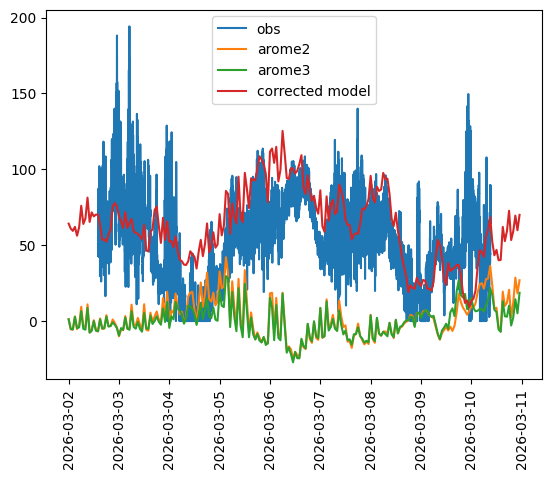

In [30]:
plt.plot(seb.index, seb['h_sens'], label='obs')
plt.plot(Arome2_seb.index, Arome2_seb['h_sens'], label='arome2') 
plt.plot(Arome3_seb.index, Arome3_seb['h_sens'], label='arome3')
plt.plot(corrected_Arome2_seb.index, corrected_Arome2_seb['h_sens'], label='corrected model')
plt.xticks(rotation=90)
plt.legend()

In [31]:
def Q_net(down_shortwave,up_shortwave, down_longwave, up_longwave, turb_sensib, turb_lat, ground_flux=0):
    """
    Calculate net radiation balance 
    Parameters
    ----------
    down_shortwave : float or array-like
        Downward shortwave radiation
    up_shortwave : float or array-like
        Downward shortwave radiation

    Returns
    -------
    s : float or ndarray
        Salinity (PSS-78)
    """
    
    down_shortwave = np.asarray(down_shortwave)
    up_shortwave = np.asarray(up_shortwave)
    down_longwave =np.asarray(down_longwave)
    up_longwave = np.asarray(up_longwave)
    turb_sensib=np.asarray(turb_sensib)
    turb_lat=np.asarray(turb_lat)
    ground_flux=np.asarray(ground_flux)


    Q_net=down_shortwave-up_shortwave+down_longwave-up_longwave+turb_sensib+turb_lat+ground_flux #+q_melt+warm_rain

    return Q_net

In [32]:
Arome2_seb['Q_net']=Q_net(Arome2_seb['SW_down_avg [W/m^2]'],Arome2_seb['SW_up_avg [W/m^2]'],Arome2_seb['LW_down_avg [W/m^2]'],Arome2_seb['LW_up_avg [W/m^2]'],Arome2_seb['h_sens'],Arome2_seb['h_lat']) 
Arome2_seb
Arome3_seb['Q_net']=Q_net(Arome3_seb['SW_down_avg [W/m^2]'],Arome3_seb['SW_up_avg [W/m^2]'],Arome3_seb['LW_down_avg [W/m^2]'],Arome3_seb['LW_up_avg [W/m^2]'],Arome3_seb['h_sens'],Arome3_seb['h_lat']) 


In [33]:
#['corrected LW_down_avg']
corrected_Arome2_seb['Q_net']=Q_net(Arome2_seb['SW_down_avg [W/m^2]'],Arome2_seb['SW_up_avg [W/m^2]'],Arome2_seb['LW_down_avg [W/m^2]']+corr_rad,Arome2_seb['LW_up_avg [W/m^2]'],corrected_Arome2_seb['h_sens'],Arome2_seb['h_lat']) 
corrected_Arome2_seb

,h_sens,Q_net
2026-03-02 00:00:00,64.219867,NaN
2026-03-02 01:00:00,60.942846,63.223313
2026-03-02 02:00:00,59.428540,59.918882
2026-03-02 03:00:00,62.063308,NaN
2026-03-02 04:00:00,56.226531,58.239474
...,...,...
2026-03-10 19:00:00,53.396513,21.692543
2026-03-10 20:00:00,59.202935,20.732132
2026-03-10 21:00:00,69.459289,NaN
2026-03-10 22:00:00,59.848382,-3.994256


In [34]:
seb_balance=Q_net(seb['short_in'],seb['short_out'],seb['long_in'],seb['long_out'], seb['h_sens'], seb['h_lat'], seb['ground'])
seb_balance=pd.DataFrame(seb_balance)
seb_balance.index=seb.index
seb_balance =seb_balance.rename({0:'net flux'}, axis=1)
#seb_balance

In [38]:
# =============================================================================
# INSTRUMENT UNCERTAINTIES
# =============================================================================

# Radiation (CNR1) - percentage based
ERR_SW_PERCENT = 0.10  # ±10% for shortwave
ERR_LW_PERCENT = 0.10  # ±10% for longwave

# Temperature (CS-215, Vaisala HMP4S, Tinytag)
ERR_T_AIR = 0.5        # °C (conservative: max of CS-215 range)
ERR_T_SURF = 0.5       # °C (surface temperature probe)

# Relative Humidity (CS-215)
ERR_RH = 4.0           # % RH

# Wind Speed (Young Wind Monitor)
ERR_WIND = 0.3         # m/s

# Air Pressure (Setra 278) - not directly used in Q_net but for vapor pressure
ERR_PRESSURE = 1.5     # hPa

# Bulk transfer coefficients (parameterization uncertainty)
ERR_A_BULK = 0.20      # 20% (typical for bulk methods)

c_pair=1004 #J/kGK at 0°C
A_bulktrans=0.0019
A_bulklat=0.0015
R_gas=287.058
q_melt=0
ground=0
warm_rain=0
rho_snow=((346.778+352.556)/2)*(10**(-3))
boltzmann=5.67*10**(-8)
rho_snow
#kappa_snow=0.138-1.01*rho_snow+3.233*(rho_snow**2)
kappa_snow=0.42
def magnus_ice (Temperature):
    e_sat=6.107*10**((9.5*Temperature)/(265+Temperature))
    return (e_sat)

In [39]:
def sensible_heat_flux_uncertainty(T_air, T_surf, wind_speed, 
                                    rho_air=1.2905, c_pair=1004, A_bulk=0.0019):
    """
    Calculate sensible heat flux with Gaussian error propagation.
    
    H = ρ * cp * A_bulk * U * (T_air - T_surf)
    
    Parameters
    ----------
    T_air, T_surf : °C
    wind_speed : m/s
    rho_air : kg/m³
    c_pair : J/(kg·K)
    A_bulk : bulk transfer coefficient
    
    Returns
    -------
    H, H_err : W/m²
    """
    # Calculate flux
    #H = rho_air * c_pair * A_bulk * wind_speed * (T_air - T_surf)
    
    # Partial derivatives
    dH_dTair = rho_air * c_pair * A_bulk * wind_speed
    dH_dTsurf = -rho_air * c_pair * A_bulk * wind_speed
    dH_dWind = rho_air * c_pair * A_bulk * (T_air - T_surf)
    dH_dAbulk = rho_air * c_pair * wind_speed * (T_air - T_surf)
    
    # Gaussian error propagation
    H_err = np.sqrt(
        (dH_dTair * ERR_T_AIR)**2 +
        (dH_dTsurf * ERR_T_SURF)**2 +
        (dH_dWind * ERR_WIND)**2 +
        (dH_dAbulk * (A_bulk * ERR_A_BULK))**2
    )
    
    return H_err

In [40]:
def latent_heat_flux_uncertainty(T_air, wind_speed, T_surf,e_air, e_surf,
                                  A_bulk=0.0015):
    """
    Calculate latent heat flux with Gaussian error propagation.
    
    LE = L_subl * A_bulk * U * (e_air - e_surf)
    where L_subl ≈ 2.83e6 J/kg (sublimation) → factor ~22.2 for hPa·m/s → W/m²
    
    Parameters
    ----------
    T_air : °C
    RH : % (0-100)
    wind_speed : m/s
    T_surf : °C (surface temperature)
    pressure : hPa
    A_bulk : bulk transfer coefficient
    
    Returns
    -------
    LE, LE_err : W/m²
    """
    # Calculate vapor pressures
    #e_air = vapor_pressure(T_air, RH, pressure)
    #e_surf = vapor_pressure(T_surf, 100.0, pressure)  # Saturated at surface
    
    # Calculate flux
    #LE = 22.2 * A_bulk * wind_speed * (e_air - e_surf)
    
    # Partial derivatives (simplified, ignoring temperature dependence of e_sat)
    dLE_de_air = 22.2 * A_bulk * wind_speed
    dLE_de_surf = -22.2 * A_bulk * wind_speed
    dLE_dWind = 22.2 * A_bulk * (e_air - e_surf)
    dLE_dAbulk = 22.2 * wind_speed * (e_air - e_surf)
    
    # Vapor pressure uncertainty (from T and RH)
    de_dT = 0.5  # hPa/°C (approximate, varies with T)
    de_dRH = e_air / 100.0  # hPa/%
    
    e_air_err = np.sqrt((de_dT * ERR_T_AIR)**2 + (de_dRH * ERR_RH)**2)
    e_surf_err = de_dT * ERR_T_SURF  # Surface assumed saturated
    
    # Gaussian error propagation
    LE_err = np.sqrt(
        (dLE_de_air * e_air_err)**2 +
        (dLE_de_surf * e_surf_err)**2 +
        (dLE_dWind * ERR_WIND)**2 +
        (dLE_dAbulk * (A_bulk * ERR_A_BULK))**2
    )
    
    return LE_err

In [41]:
def Q_net_full_uncertainty(seb_df, T_air, T_surf, U_wind, e_air, e_surf, ground):
    """
    Calculate net surface energy balance with full Gaussian error propagation.
    
    Q_net = SW↓ - SW↑ + LW↓ - LW↑ + H + LE + G
    
    Parameters
    ----------
    seb_df : DataFrame with columns:
        - down_shortwave, up_shortwave (W/m²)
        - down_longwave, up_longwave (W/m²)
        - T_air, T_surf (°C)
        - RH (%)
        - wind_speed (m/s)
        - ground_flux (W/m², optional)
    
    Returns
    -------
    seb_df : DataFrame with added columns:
        - h_sens, h_sens_err (W/m²)
        - h_lat, h_lat_err (W/m²)
        - Q_net, Q_net_err (W/m²)
        - Individual component uncertainties
    """
    df = seb_df.copy()

    # ---- Radiation uncertainties (percentage based) ----
    df['err_down_sw'] = ERR_SW_PERCENT * seb_df['short_in'].abs()
    df['err_up_sw'] = ERR_SW_PERCENT * seb_df['short_out'].abs()
    df['err_down_lw'] = ERR_LW_PERCENT * seb_df['long_in'].abs()
    df['err_up_lw'] = ERR_LW_PERCENT * seb_df['long_out'].abs()
    
    # ---- Sensible heat flux with uncertainty ----
    df['h_sens_err'] = sensible_heat_flux_uncertainty(
        T_air=T_air,
        T_surf=T_surf,
        wind_speed=U_wind
    )


     # ---- Latent heat flux with uncertainty ----
    df['h_lat_err'] = latent_heat_flux_uncertainty(
        T_air=T_air,
        wind_speed=U_wind,
        T_surf=T_surf,
        e_air=e_air,
        e_surf=e_surf
    )
  
    #------Ground heat flux uncertainty------
    df['err_ground'] = 0.10 * ground.abs()

    # ---- Gaussian error propagation for Q_net ----
    # σ_Q = sqrt(σ_SW↓² + σ_SW↑² + σ_LW↓² + σ_LW↑² + σ_H² + σ_LE² + σ_G²)
    df['Q_net_err'] = np.sqrt(
        df['err_down_sw']**2 + 
        df['err_up_sw']**2 + 
        df['err_down_lw']**2 + 
        df['err_up_lw']**2 + 
        df['h_sens_err']**2 + 
        df['h_lat_err']**2 + 
        df['err_ground']**2
    )
    
    return df

In [42]:
uncertainties=Q_net_full_uncertainty(seb, Tbn_upper_upper['T [degC]'], seb['T_surf'],Tbn_upper_upper['Speed_wind [m/s]'],Tbn_upper_upper['e_air'], seb['E_sat_ice_surf'],seb['ground']) 

In [43]:
error_means = uncertainties.filter(like='err').mean()
print(error_means)

err_down_sw     1.038533
err_up_sw       0.912338
err_down_lw    26.022924
err_up_lw      26.974285
h_sens_err     21.631157
h_lat_err       0.127608
err_ground      0.102790
Q_net_err      44.413829
dtype: float64


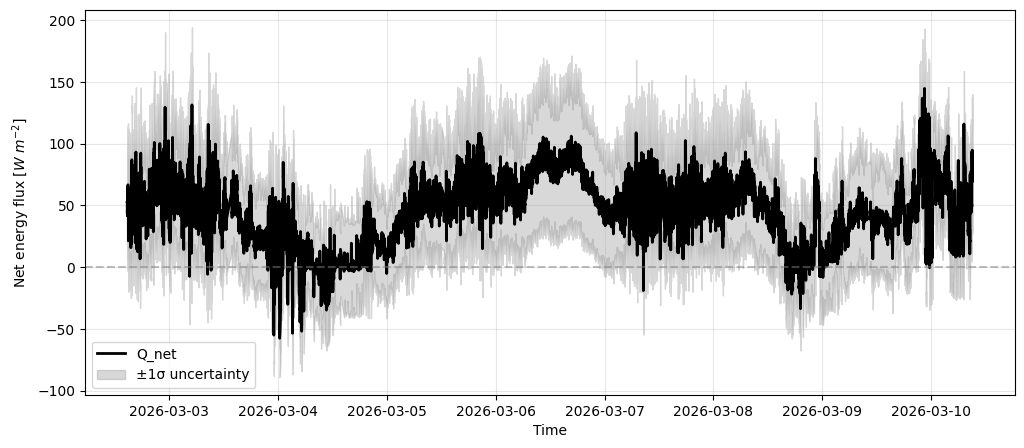

In [44]:

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(seb_balance.index, seb_balance['net flux'], label='Q_net', color='black', linewidth=2)
ax.fill_between(seb_balance.index, 
                seb_balance['net flux'] - uncertainties['Q_net_err'], 
                seb_balance['net flux'] + uncertainties['Q_net_err'],
                alpha=0.3, color='gray', label='±1σ uncertainty')

ax.axhline(0, linestyle='--', color='gray', alpha=0.5)
ax.set_ylabel(r'Net energy flux [$W\ m^{-2}$]')
ax.set_xlabel('Time')
ax.legend()
ax.grid(alpha=0.3)

#plt.savefig('Q_net_with_uncertainty.png', dpi=300)
plt.show()

Text(0.5, 0, 'Time')

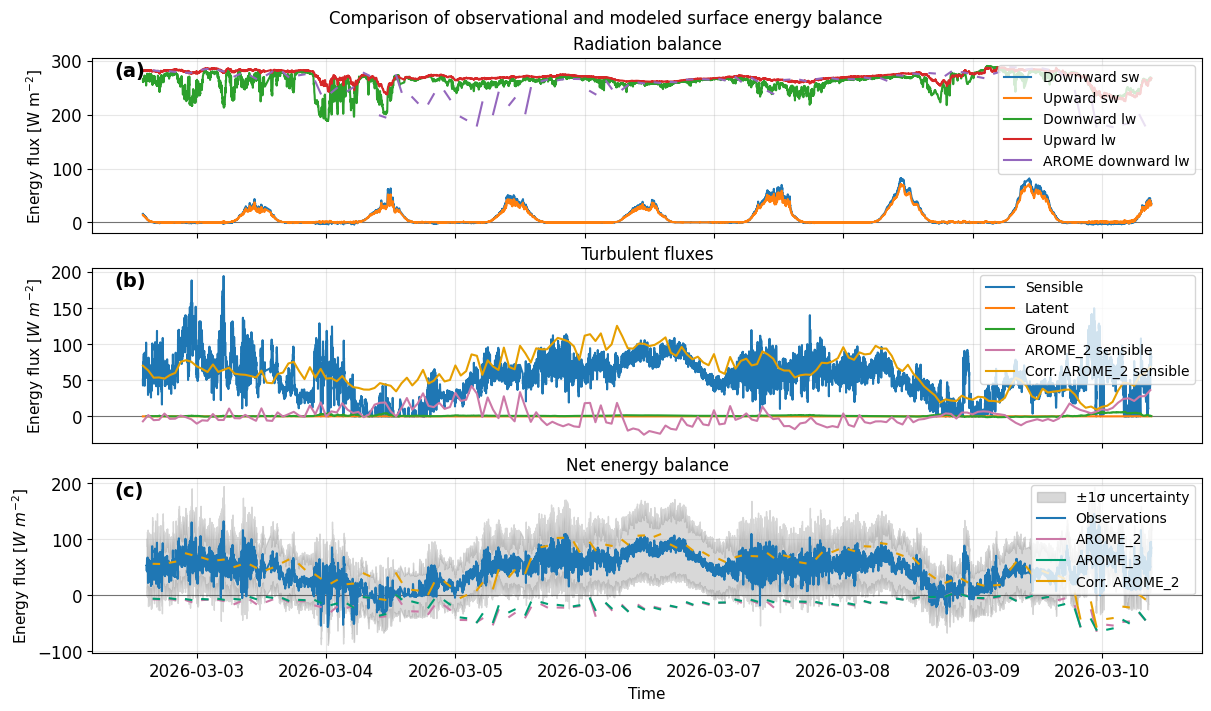

In [45]:
Arome2_seb= Arome2_seb.loc['2026-03-02 14:00:00':'2026-03-10 09:10:00']
Arome3_seb= Arome3_seb.loc['2026-03-02 14:00:00':'2026-03-10 09:10:00']
corrected_Arome2_seb=corrected_Arome2_seb.loc['2026-03-02 14:00:00':'2026-03-10 09:10:00']

fig, axs=plt.subplots(3,1,figsize=(12,7), sharex=True, constrained_layout=True)
for ax in axs:
    ax.grid(alpha=0.3)
    ax.axhline(0, color='k', lw=0.8, alpha=0.5)
    ax.tick_params(labelsize=12)

for i, ax in enumerate(axs):
    ax.text(0.02, 0.98, f'({chr(97+i)})', transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='left')
fig.suptitle('Comparison of observational and modeled surface energy balance')
axs[0].set_title('Radiation balance')
axs[0].set_ylabel(r'Energy flux [$\text{W}\ \text{m}^{-2}$]',fontsize=11)
axs[0].plot(seb.index, seb['short_in'], label='Downward sw')
axs[0].plot(seb.index,seb['short_out'], label='Upward sw')
axs[0].plot(seb.index,seb['long_in'], label='Downward lw')
axs[0].plot(seb.index,seb['long_out'], label='Upward lw')
axs[0].plot(Arome2_seb.index,Arome2_seb['LW_down_avg [W/m^2]'], label='AROME downward lw')
axs[0].legend(loc='upper right')
axs[1].set_title('Turbulent fluxes')
axs[1].set_ylabel(r'Energy flux [$W\ m^{-2}$]', fontsize=11)
#axs[1].fill_between(seb.index, 
#                seb['h_sens'] - uncertainties['h_sens_err'], 
#                seb['h_sens'] + uncertainties['h_sens_err'],
#                alpha=0.3, color='gray', label='±1σ uncertainty')
axs[1].plot(seb.index,seb['h_sens'],label='Sensible')
axs[1].plot(seb.index,seb['h_lat'],label='Latent')
axs[1].plot(seb.index,seb['ground'], label='Ground')
axs[1].plot(Arome2_seb.index,Arome2_seb['h_sens'], label='AROME_2 sensible', color='#CC79A7')
axs[1].plot(corrected_Arome2_seb.index,corrected_Arome2_seb['h_sens'], label='Corr. AROME_2 sensible', color='#E69F00')
axs[1].legend(loc='upper right')

axs[2].set_title('Net energy balance')
axs[2].set_ylabel(r'Energy flux [$W\ m^{-2}$]', fontsize=11)
axs[2].fill_between(seb_balance.index, 
                seb_balance['net flux'] - uncertainties['Q_net_err'], 
                seb_balance['net flux'] + uncertainties['Q_net_err'],
                alpha=0.3, color='gray', label='±1σ uncertainty')
axs[2].plot(seb_balance.index, seb_balance['net flux'],label='Observations')
axs[2].plot(Arome2_seb.index, Arome2_seb['Q_net'], label='AROME_2',color='#CC79A7', ls='-')
axs[2].plot(Arome3_seb.index, Arome3_seb['Q_net'], label='AROME_3', ls='-', color='#009E73')
axs[2].plot(corrected_Arome2_seb.index, corrected_Arome2_seb['Q_net'], label='Corr. AROME_2', ls='-', color='#E69F00')
axs[2].legend(loc='upper right')
axs[2].set_xlabel('Time', fontsize=11)

#fig.savefig('seb.png')

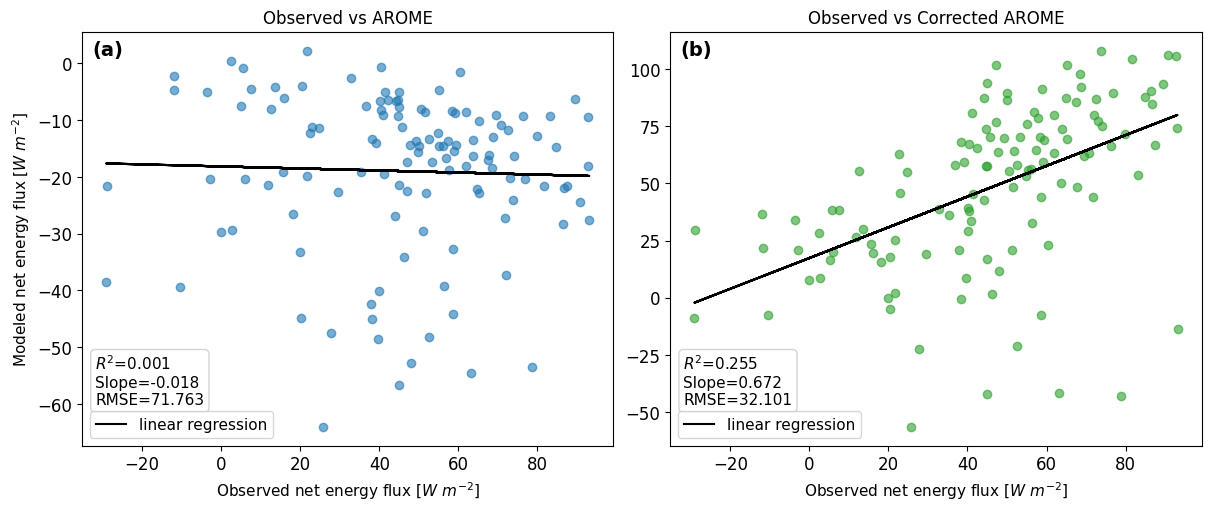

In [46]:
from sklearn.metrics import mean_squared_error

# Align time indices
from scipy.stats import linregress
#from sklearn.metrics import mean_squared_error
common_index = seb_balance.index.intersection(Arome2_seb.index)

obs = seb_balance.loc[common_index, 'net flux']
mod = Arome2_seb.loc[common_index, 'Q_net']
mod_corr = corrected_Arome2_seb.loc[common_index, 'Q_net']
mask = np.isfinite(obs) & np.isfinite(mod)

obs_clean = obs[mask]
mod_clean = mod[mask]
mod_corr_clean = mod_corr[mask]



reg1 = linregress(obs_clean, mod_clean)
reg2 = linregress(obs_clean, mod_corr_clean)


#mse = mean_squared_error(y_true=y, y_pred=y_pred, squared=True)
rmse1 = np.sqrt(mean_squared_error(y_true=obs_clean, y_pred=mod_clean))
rmse2 = np.sqrt(mean_squared_error(y_true=obs_clean, y_pred=mod_corr_clean))

fig, ax = plt.subplots(1, 2, figsize=(12,5), constrained_layout=True)

# ---------- Original AROME ----------
ax[0].scatter(obs_clean, mod_clean, color='tab:blue', alpha=0.6)
ax[0].plot(obs_clean, reg1.intercept + reg1.slope * obs_clean, color='black', label='linear regression')

ax[0].set_title('Observed vs AROME',fontsize=12)
ax[0].set_xlabel(r'Observed net energy flux [$W\ m^{-2}$]', fontsize=11)
ax[0].set_ylabel(r'Modeled net energy flux [$W\ m^{-2}$]',fontsize=11)
ax[0].tick_params(labelsize=12)
ax[0].text(0.025, 0.10,
           f'$R^2$={reg1.rvalue**2:.3f}\nSlope={reg1.slope:.3f}\nRMSE={rmse1:.3f}',
           transform=ax[0].transAxes, bbox=dict(facecolor='white',boxstyle='round',edgecolor='lightgray'),fontsize=11)

# ---------- Corrected ----------
ax[1].scatter(obs_clean, mod_corr_clean, color='tab:green', alpha=0.6)
ax[1].plot(obs_clean, reg2.intercept + reg2.slope * obs_clean, color='black', label='linear regression')

ax[1].set_title('Observed vs Corrected AROME', fontsize=12)
ax[1].set_xlabel(r'Observed net energy flux [$W\ m^{-2}$]',fontsize=11)
ax[1].tick_params(labelsize=12)
ax[1].text(0.025, 0.10,
           f'$R^2$={reg2.rvalue**2:.3f}\nSlope={reg2.slope:.3f}\nRMSE={rmse2:.3f}',
           transform=ax[1].transAxes, bbox=dict(facecolor='white',boxstyle='round',edgecolor='lightgray'), fontsize=11)
ax[0].legend(loc='lower left',fontsize=11)
ax[1].legend(loc='lower left',fontsize=11)
for i, ax in enumerate(ax):
    ax.text(0.02, 0.98, f'({chr(97+i)})', transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='left')
#plt.savefig('seb_model_comp.png')
plt.show()
#print(rmse1, rmse2)
#bbox=dict(facecolor='white', alpha=0.)

In [47]:
#from sklearn.metrics import mean_squared_error

def calc_rmse(obs, mod, var_name):
    """Calculate RMSE and R^2 between observed and modeled values."""
    
    obs, mod = obs.align(mod, join='inner')
    
    mask = np.isfinite(obs) & np.isfinite(mod)
    obs = obs[mask]
    mod = mod[mask]
    
    reg = linregress(obs, mod)
    r_square=reg.rvalue**2
    rmse = np.sqrt(mean_squared_error(y_true=obs, y_pred=mod))
    return {'Variable': var_name,'Sample length': len(obs), 'RMSE': round(rmse, 3), r'$R_{square}$':round(r_square, 3)}

# Calculate RMSE for multiple comparisons
rmse_results = [
    #calc_rmse(obs_clean, mod_clean, 'Net Flux (Original)'),
    #calc_rmse(obs_clean, mod_corr_clean, 'Net Flux (Corrected)'),
    calc_rmse(Tbn_upper_lower['T [degC]'], Arome2_seb['T_2m'],'Temperature'),
    calc_rmse(seb['h_sens'],seb_balance['net flux'], 'heat flux'),
    calc_rmse(seb['T_surf'], Arome2_seb['T_surf'], 'T_surf')
    # Add more as needed
]

# Convert to DataFrame
RMSE_values = pd.DataFrame(rmse_results)
#print(RMSE_values)

table_lat=RMSE_values.to_latex(index=False,float_format="%.3f",column_format='|l|c|c|c|', escape=False)
print(table_lat)

\begin{tabular}{|l|c|c|c|}
\toprule
Variable & Sample length & RMSE & $R_{square}$ \\
\midrule
Temperature & 184 & 1.371 & 0.808 \\
heat flux & 11006 & 14.381 & 0.820 \\
T_surf & 184 & 2.000 & 0.623 \\
\bottomrule
\end{tabular}

